# Covariance-Weighted Tikhonov Regularization — GMM Memorization Study

Follow-up to `edm_tikhonov_memorization.ipynb`. There, Tikhonov regularization used the
isotropic norm ‖s‖², giving the closed-form GMM score denominator σ² + c at every Fourier mode.

**This experiment** replaces the isotropic norm with the covariance-weighted norm
‖s‖²_Σ = sᵀ Σ⁻¹ s, where Σ is the covariance of the training data (per the professor's plan).
Modes where the data has small variance (high wavenumbers) are penalized more, so the
regularization becomes scale-selective: it should de-memorize fine scales at much smaller c
while leaving coarse scales untouched.

**Closed form.** The regularized DSM objective at time t is

$$ J(s) + \frac{c}{\sigma^2}\,\mathbb{E}\,\|s\|_\Sigma^2, \qquad \|v\|_\Sigma^2 = v^\top \Sigma^{-1} v. $$

Pointwise stationarity gives $(I + \frac{c}{\sigma^2}\Sigma^{-1})\,s^* = \bar{s}$, with
$\bar{s} = (m(t)\,\bar{x}(x) - x)/\sigma^2$ the unregularized GMM score. In the eigenbasis
of Σ (eigenvalues $\lambda_i$):

$$ s^*_i = \frac{(m\,\bar{x} - x)_i}{\sigma^2 + c/\lambda_i}. $$

The isotropic case is recovered by $\lambda_i \equiv 1$ (denominator σ² + c). Covariance
weighting replaces the constant c with the mode-dependent constant c/λᵢ — small-λ (fine)
modes get a much larger effective constant, exactly the "penalize higher-order modes more"
behavior we want.

**Key implementation choices (see the λ-spectrum cell for the measured numbers):**
1. The fields are stationary, so Σ is diagonalized by the 2-D Fourier basis and λ is the
   per-mode power spectrum of the centered training data — Σ⁻¹ is applied exactly via FFT,
   no 16384×16384 matrix inversion needed.
2. With unit-variance data and an orthonormal FFT, mean(λ) ≈ 1, so c here is on the same
   scale as the isotropic constant in the previous sweep.
3. **Null modes.** The data is strictly band-limited (k < 32) and mean-normalized, so λ = 0
   for out-of-band modes and DC (measured ~1e-12 vs in-band minimum ~9e-3). A literal Σ⁻¹
   would infinitely penalize the score there, zeroing it, and the reverse SDE would fill
   those modes with noise. We use pseudo-inverse semantics instead: modes below a relative
   threshold get NO regularization, keeping the unregularized score that correctly pulls
   them to zero. See open questions at the end.

Setup mirrors the GMM comparison in `edm_tikhonov_memorization.ipynb`: n_train = 32, VE_EDM
diffusion, 500-step SDE, 16 generated samples from latents fixed by seed 42.

In [1]:
import sys, os, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import (
    generate_multiband_dataset_postmask,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


In [2]:
# ── Data generation (same as edm_tikhonov_memorization) ──
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
x_all = result['combined']  # (200, 128, 128)

N_TRAIN = 32
N = 128
x_train_img = x_all[:N_TRAIN].to(device)            # (32, 128, 128)
train_data_flat = x_train_img.reshape(N_TRAIN, -1)   # (32, 16384)

print(f'x_train_img: {x_train_img.shape}, train_data_flat: {train_data_flat.shape}')
print(f'sigma_data (std of training data): {train_data_flat.std().item():.4f}')

x_train_img: torch.Size([32, 128, 128]), train_data_flat: torch.Size([32, 16384])
sigma_data (std of training data): 0.9982


mean(lam) = 0.9687 (≈ data variance)
null modes (λ ≈ 0): 13180 / 16384 (out-of-band k>32 and DC — the data is band-limited)
  band coarse [ 0.5,  4.0): mean λ = 3.411e+02,  min λ = 6.344e+01
  band   mid1 [ 4.0, 10.0): mean λ = 2.657e+00,  min λ = 8.293e-01
  band   mid2 [10.0, 18.0): mean λ = 1.593e-01,  min λ = 4.789e-02
  band   fine [18.0, 32.0): mean λ = 2.743e-02,  min λ = 9.117e-03


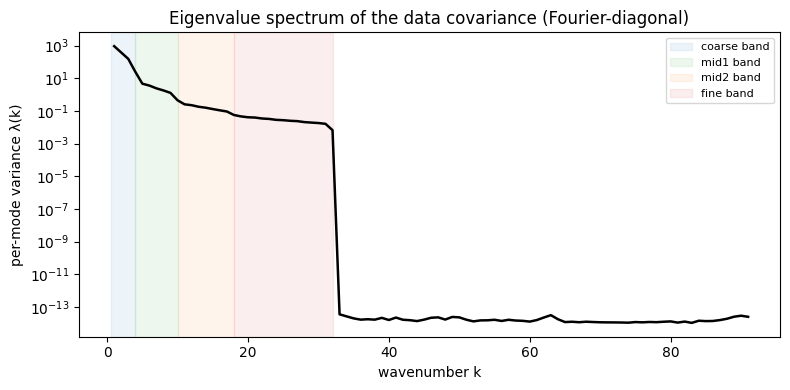

In [3]:
# ── Empirical covariance spectrum λ(k) ──
# The fields are stationary, so the data covariance is diagonal in the 2-D Fourier basis:
# Σ = Fᴴ diag(λ) F. λ is estimated per mode from the centered training set. With
# norm='ortho' and unit-variance data, mean(λ) ≈ 1, so the Tikhonov constant c is on the
# same scale as the isotropic sweep in edm_tikhonov_memorization.ipynb.

x_train_centered = x_train_img - x_train_img.mean(dim=0, keepdim=True)
X_train = torch.fft.fft2(x_train_centered, dim=(-2, -1), norm='ortho')
lam = (X_train.abs() ** 2).mean(dim=0)          # (N, N) per-mode variance

NULL_REL_THRESHOLD = 1e-6                        # modes with λ < thr·mean(λ) -> null space
null_mask_lam = lam < NULL_REL_THRESHOLD * lam.mean()

kr = make_radial_k_grid(N, device=device)
print(f'mean(lam) = {lam.mean():.4f} (≈ data variance)')
print(f'null modes (λ ≈ 0): {null_mask_lam.sum().item()} / {N*N} '
      f'(out-of-band k>32 and DC — the data is band-limited)')
for name, (lo, hi) in bands.items():
    m = (kr >= lo) & (kr < hi)
    print(f'  band {name:>6} [{lo:>4},{hi:>5}): mean λ = {lam[m].mean():.3e},  min λ = {lam[m].min():.3e}')

# Radial profile of λ
k_flat = kr.flatten().cpu().numpy()
lam_flat = lam.flatten().cpu().numpy()
kbins = np.arange(0.5, k_flat.max() + 1.5, 1.0)
kmid = 0.5 * (kbins[1:] + kbins[:-1])
lam_radial = np.array([lam_flat[(k_flat >= lo) & (k_flat < hi)].mean()
                       for lo, hi in zip(kbins[:-1], kbins[1:])])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(kmid, np.clip(lam_radial, 1e-14, None), color='black', lw=1.8)
for bname, color in [('coarse', 'tab:blue'), ('mid1', 'tab:green'),
                     ('mid2', 'tab:orange'), ('fine', 'tab:red')]:
    lo, hi = bands[bname]
    ax.axvspan(lo, hi, color=color, alpha=0.08, label=f'{bname} band')
ax.set_xlabel('wavenumber k')
ax.set_ylabel('per-mode variance λ(k)')
ax.set_title('Eigenvalue spectrum of the data covariance (Fourier-diagonal)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Covariance-weighted score class

Denominator per Fourier mode: σ² + c/λ(k). With the measured spectrum this means, e.g. at
c = 0.01: effective constant ≈ 3e-5 in the coarse band (mean λ ≈ 340) but ≈ 0.4 in the fine
band (mean λ ≈ 0.027) — four orders of magnitude of scale selectivity from one scalar c.
The isotropic sweep needed c ≈ 0.1–1 to visibly affect fine scales; here the same fine-band
effect should appear around c ≈ 1e-3–1e-2, with essentially no effect on the coarse band.

In [4]:
class GMM_score_CovarianceTikhonov(score_models.GMM_score):
    '''
    GMM score with covariance-weighted Tikhonov regularization.

    Regularized DSM objective at time t:  J(s) + (c/σ²)·E‖s‖²_Σ,  ‖v‖²_Σ = vᵀΣ⁻¹v,
    with Σ the covariance of the training data. Stationary point in the eigenbasis of Σ:

        s*_i = (m(t)·x̄(x) − x)_i / (σ² + c/λ_i)

    i.e. the isotropic Tikhonov denominator σ² + c with c replaced by the mode-dependent
    constant c/λ_i. Modes where the data variance λ_i is small (fine scales) are damped
    harder; λ ≡ 1 recovers GMM_score_TikhonovRegularized exactly.

    The fields are stationary, so Σ is diagonal in the 2-D Fourier basis and λ is the
    per-mode power spectrum of the (centered) training data, estimated with an orthonormal
    FFT so that mean(λ) ≈ data variance ≈ 1.

    Null modes: where λ < null_rel_threshold·mean(λ) (out-of-band k > 32 and DC — the data
    is band-limited), Σ is singular and a literal Σ⁻¹ penalty would be infinite, zeroing
    the score and letting the reverse SDE fill those modes with noise. We use pseudo-inverse
    semantics instead: those modes are left unregularized, so the unregularized score keeps
    pulling them to zero (the data content there).
    '''
    def __init__(self, train_data, marginal_prob_mean, marginal_prob_std, grid_size,
                 constant=1.0, spectrum=None, null_rel_threshold=1e-6):
        super().__init__(train_data, marginal_prob_mean, marginal_prob_std)
        self.grid_size = grid_size
        self.constant = constant
        if spectrum is None:
            imgs = train_data.reshape(-1, grid_size, grid_size)
            imgs = imgs - imgs.mean(dim=0, keepdim=True)
            X = torch.fft.fft2(imgs, dim=(-2, -1), norm='ortho')
            spectrum = (X.abs() ** 2).mean(dim=0)              # (N, N) per-mode variance
        null_mask = spectrum < null_rel_threshold * spectrum.mean()
        c_eff = torch.where(null_mask, torch.zeros_like(spectrum),
                            constant / spectrum.clamp_min(1e-30))
        self.register_buffer('spectrum_buf', spectrum)
        self.register_buffer('c_eff', c_eff)
        self.register_buffer('null_mask', null_mask)

    def forward(self, x, t):
        # softmax mixture weights and posterior mean, same as GMM_score
        weights = self.pdf_weights(x, t)
        sigma = self.marginal_prob_std(t)
        evals = self.marginal_prob_mean(t)[:, None] * torch.mm(weights, self.train_data)
        evals[torch.isnan(evals)] = 0.0
        # mode-dependent denominator σ² + c/λ, applied in Fourier space
        Ngrid = self.grid_size
        resid = (evals - x).reshape(-1, Ngrid, Ngrid)
        R = torch.fft.fft2(resid, dim=(-2, -1), norm='ortho')
        denom = sigma[:, None, None] ** 2 + self.c_eff[None, :, :]
        score = torch.fft.ifft2(R / denom, dim=(-2, -1), norm='ortho').real
        return score.reshape(x.shape)


print('GMM_score_CovarianceTikhonov defined.')

GMM_score_CovarianceTikhonov defined.


In [5]:
# ── Sanity checks ──
# 1) c = 0 reduces to the plain GMM score.
# 2) λ ≡ 1 reduces to the isotropic GMM_score_TikhonovRegularized with the same c.

diff_check = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)
torch.manual_seed(0)
x_chk = torch.randn(4, N*N, device=device)
t_chk = torch.rand(4, device=device) * 0.6 + 0.2   # mid-range t, scores are O(1)

s_cov0 = GMM_score_CovarianceTikhonov(train_data_flat, diff_check.marginal_prob_mean,
                                      diff_check.marginal_prob_std, N, constant=0.0)(x_chk, t_chk)
s_gmm = score_models.GMM_score(train_data_flat, diff_check.marginal_prob_mean,
                               diff_check.marginal_prob_std)(x_chk, t_chk)
rel0 = ((s_cov0 - s_gmm).abs().max() / s_gmm.abs().max()).item()

s_cov1 = GMM_score_CovarianceTikhonov(train_data_flat, diff_check.marginal_prob_mean,
                                      diff_check.marginal_prob_std, N, constant=0.37,
                                      spectrum=torch.ones(N, N, device=device))(x_chk, t_chk)
s_tik = score_models.GMM_score_TikhonovRegularized(train_data_flat, diff_check.marginal_prob_mean,
                                                   diff_check.marginal_prob_std,
                                                   diff_check.diffusion_coeff, constant=0.37)(x_chk, t_chk)
rel1 = ((s_cov1 - s_tik).abs().max() / s_tik.abs().max()).item()

print(f'c=0 vs GMM_score:                     max rel diff = {rel0:.2e}')
print(f'λ≡1 vs GMM_score_TikhonovRegularized: max rel diff = {rel1:.2e}')
assert rel0 < 1e-4 and rel1 < 1e-4, 'covariance-weighted class does not reduce to known cases'

c=0 vs GMM_score:                     max rel diff = 1.79e-07
λ≡1 vs GMM_score_TikhonovRegularized: max rel diff = 1.94e-07


In [6]:
# ── Analysis helpers (same as edm_tikhonov_memorization / analyze_coarse_fine_memorization.py) ──

@torch.no_grad()
def band_component(x, band, norm='forward'):
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb
    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)  # (n_ref, G, K)


def ring_idx_for_band(band, k_centers):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


@torch.no_grad()
def radial_power_spectrum(x, ring_masks_):
    """Mean per-mode power in each wavenumber ring (orthonormal FFT), averaged over batch."""
    X = torch.fft.fft2(x, dim=(-2, -1), norm='ortho')
    P = X.abs() ** 2
    rm = ring_masks_.to(x.device)
    num = (P.unsqueeze(1) * rm.unsqueeze(0)).sum(dim=(-2, -1))   # (G, K)
    cnt = rm.sum(dim=(-2, -1)).clamp_min(1)
    return (num / cnt).mean(dim=0)                               # (K,)


# Precompute wavenumber grid and ring masks
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
ring_masks = make_ring_masks(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])
coarse_r = ring_idx_for_band(bands['coarse'], k_centers)
fine_r   = ring_idx_for_band(bands['fine'],   k_centers)
print(f'Ring masks: {ring_masks.shape}, k range: [{k_centers[0]:.1f}, {k_centers[-1]:.1f}]')

Ring masks: torch.Size([91, 128, 128]), k range: [1.0, 91.0]


In [7]:
# ── Sweep: isotropic vs covariance-weighted Tikhonov (GMM closed form, VE_EDM) ──
# Same C list for both methods so the panels are directly comparable. Since mean(λ) ≈ 1,
# c is on a common scale; the covariance-weighted effect on the fine band should appear
# ~2 orders of magnitude earlier in c.
# c = 0 runs are identical for both methods by construction (kept for a uniform loop).
# Runtime: 14 runs x 500 SDE steps with the n_train=32 GMM score — a few minutes on CPU.

N_GEN = 16
N_SDE_STEPS = 500
N_RAND_REF = 32
C_VALUES = [0.0, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 5.0]

ve_edm = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)
xtr = x_train_img.detach()
spectrum_train = radial_power_spectrum(xtr, ring_masks)   # reference data spectrum


def make_score(method, c_val):
    if c_val == 0.0:
        return score_models.GMM_score(train_data_flat, ve_edm.marginal_prob_mean,
                                      ve_edm.marginal_prob_std).to(device)
    if method == 'isotropic':
        return score_models.GMM_score_TikhonovRegularized(
            train_data_flat, ve_edm.marginal_prob_mean, ve_edm.marginal_prob_std,
            ve_edm.diffusion_coeff, constant=c_val).to(device)
    return GMM_score_CovarianceTikhonov(
        train_data_flat, ve_edm.marginal_prob_mean, ve_edm.marginal_prob_std, N,
        constant=c_val, null_rel_threshold=NULL_REL_THRESHOLD).to(device)


results = {'isotropic': {}, 'covariance': {}}

for method in results:
    print(f'--- {method} ---')
    for c_val in C_VALUES:
        score_fn = make_score(method, c_val)
        torch.manual_seed(42)                      # same latents for every run
        latents = torch.randn(N_GEN, N*N, device=device)
        samples = ve_edm.SDEsampler(score_fn, latents, num_steps=N_SDE_STEPS)
        x_gen = samples.reshape(N_GEN, N, N)

        idx_nn, _ = nn_by_coarse(x_gen, xtr, bands['coarse'])
        err_nn = ring_rel_l2(x_gen, xtr[idx_nn], ring_masks)
        err_rand = random_baseline_errors(x_gen, xtr, ring_masks, n_ref=N_RAND_REF)
        ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)   # (G, K)

        cs = ratio[:, coarse_r].mean(dim=1)
        fs = ratio[:, fine_r].mean(dim=1)
        results[method][c_val] = {
            'mean_ratio': ratio.mean(dim=0).cpu(),
            'coarse_score': cs.mean().item(),
            'fine_score': fs.mean().item(),
            'gen_spectrum': radial_power_spectrum(x_gen, ring_masks).cpu(),
            'samples': x_gen[:4].cpu(),
        }
        print(f'  c={c_val:<8g} coarse={cs.mean():.4f}  fine={fs.mean():.4f}')

print('\nSweep complete.')

--- isotropic ---
  c=0        coarse=0.0294  fine=0.0375
  c=0.0001   coarse=0.0297  fine=0.0710
  c=0.001    coarse=0.0305  fine=0.1586
  c=0.01     coarse=0.0331  fine=0.4065
  c=0.1      coarse=0.0413  fine=0.7991
  c=1        coarse=0.0683  fine=0.9716
  c=5        coarse=0.1196  fine=0.9936
--- covariance ---
  c=0        coarse=0.0294  fine=0.0375
  c=0.0001   coarse=0.0294  fine=0.2781
  c=0.001    coarse=0.0294  fine=0.6301
  c=0.01     coarse=0.0295  fine=0.9194
  c=0.1      coarse=0.0300  fine=0.9900
  c=1        coarse=0.0317  fine=0.9987
  c=5        coarse=0.0346  fine=0.9997

Sweep complete.


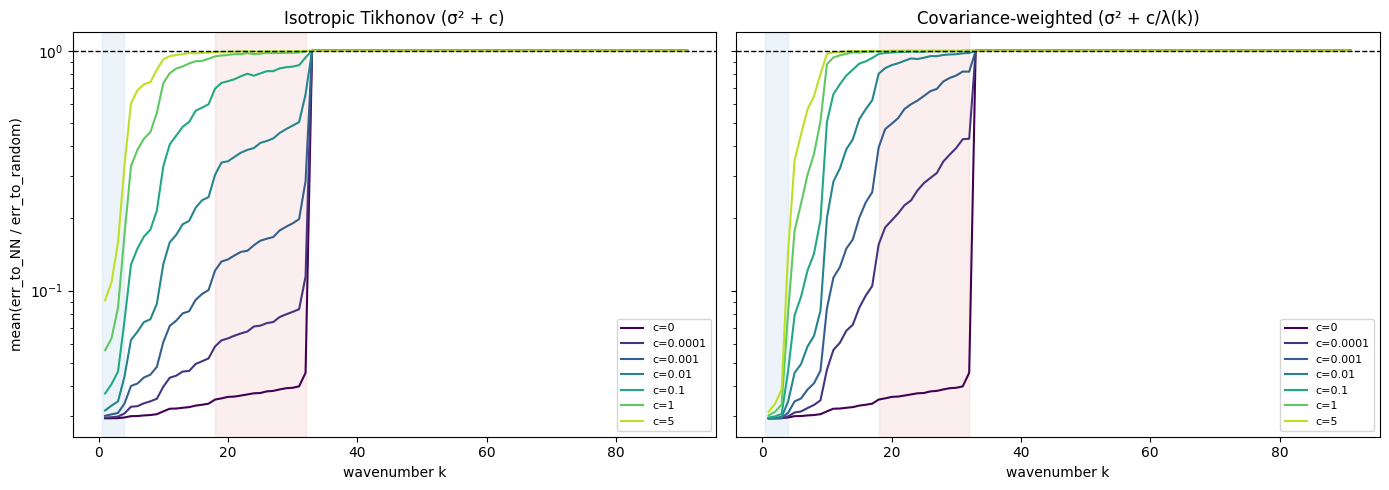

In [8]:
# ── Per-wavenumber memorization: isotropic vs covariance-weighted ──
kc = k_centers.cpu().numpy()
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(C_VALUES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, method, title in zip(axes, ['isotropic', 'covariance'],
                             ['Isotropic Tikhonov (σ² + c)',
                              'Covariance-weighted (σ² + c/λ(k))']):
    for i, c_val in enumerate(C_VALUES):
        ax.plot(kc, results[method][c_val]['mean_ratio'].numpy(),
                color=cmap[i], label=f'c={c_val:g}', linewidth=1.5)
    ax.axhline(1.0, ls='--', color='black', lw=1)
    for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=color, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean(err_to_NN / err_to_random)')
plt.tight_layout()
plt.show()

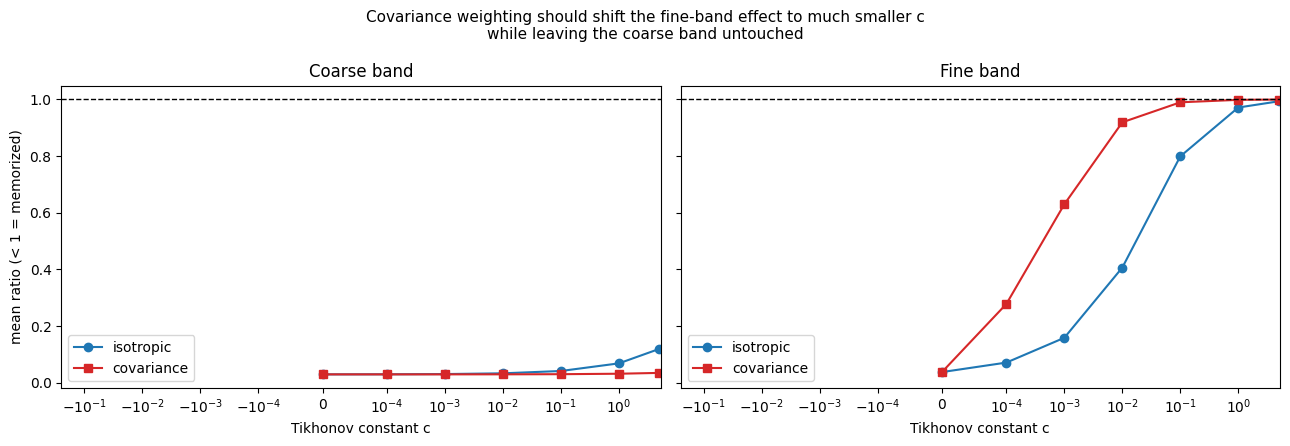

In [9]:
# ── Coarse/fine band scores vs c ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, band_key, title in zip(axes, ['coarse_score', 'fine_score'],
                               ['Coarse band', 'Fine band']):
    for method, marker, color in [('isotropic', 'o', 'tab:blue'),
                                  ('covariance', 's', 'tab:red')]:
        vals = [results[method][c][band_key] for c in C_VALUES]
        ax.plot(C_VALUES, vals, marker + '-', color=color, label=method)
    ax.axhline(1.0, ls='--', color='black', lw=1)
    ax.set_xscale('symlog', linthresh=1e-4)
    ax.set_xlabel('Tikhonov constant c')
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel('mean ratio (< 1 = memorized)')
fig.suptitle('Covariance weighting should shift the fine-band effect to much smaller c\n'
             'while leaving the coarse band untouched', fontsize=11)
plt.tight_layout()
plt.show()

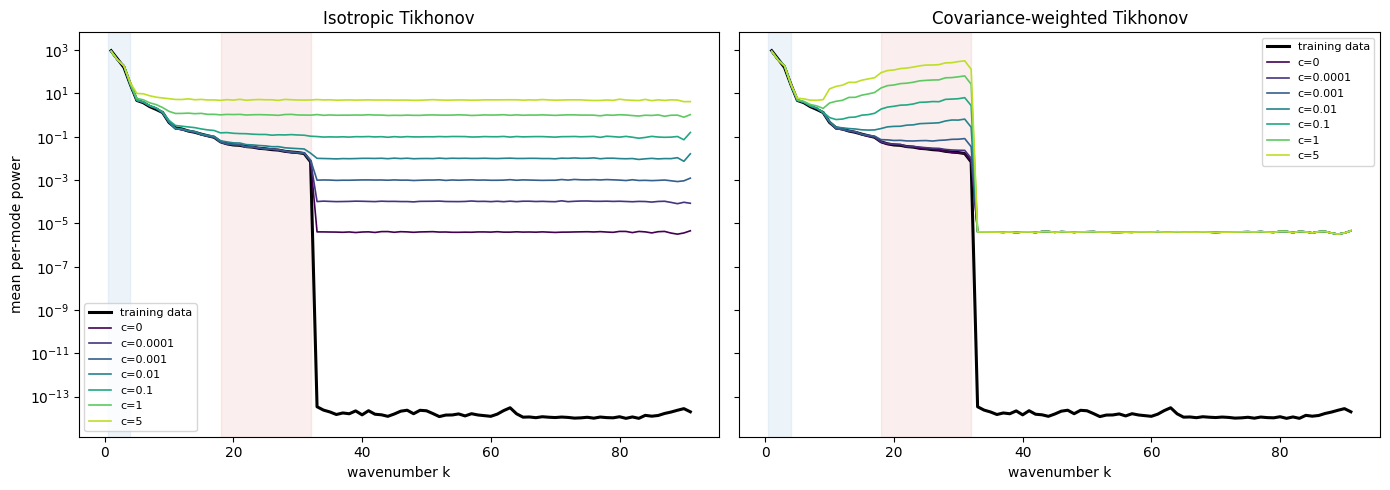

In [10]:
# ── Generated radial power spectra vs training data ──
# Shows where each regularizer injects/removes power. Damped modes end up with a noise
# floor ≈ the effective constant: c everywhere for the isotropic version (including
# out-of-band k > 32), c/λ(k) in-band for the covariance-weighted version (out-of-band
# modes stay clean thanks to the null-mode handling).

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, method, title in zip(axes, ['isotropic', 'covariance'],
                             ['Isotropic Tikhonov', 'Covariance-weighted Tikhonov']):
    ax.semilogy(kc, np.clip(spectrum_train.cpu().numpy(), 1e-14, None),
                color='black', lw=2.2, label='training data')
    for i, c_val in enumerate(C_VALUES):
        ax.semilogy(kc, np.clip(results[method][c_val]['gen_spectrum'].numpy(), 1e-14, None),
                    color=cmap[i], lw=1.2, label=f'c={c_val:g}')
    for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=color, alpha=0.08)
    ax.set_xlabel('wavenumber k')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean per-mode power')
plt.tight_layout()
plt.show()

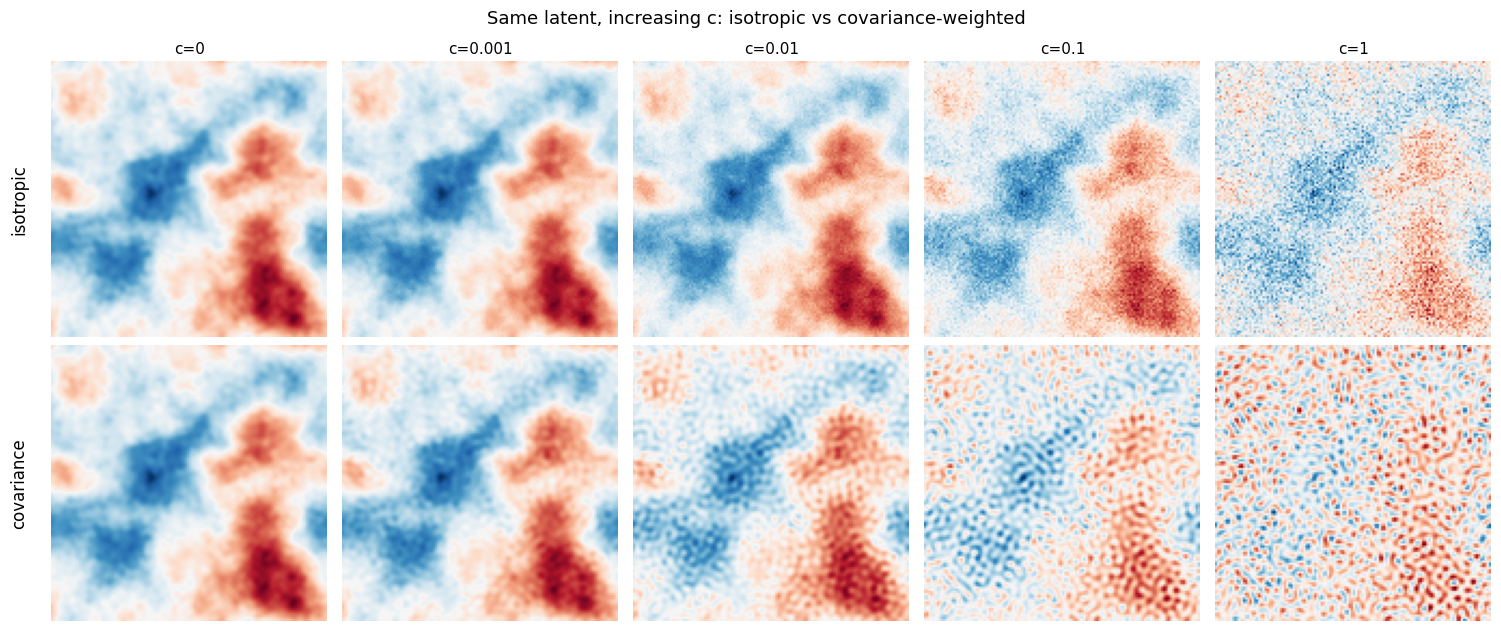

In [11]:
# ── Visual comparison of generated samples (same latent, increasing c) ──
show_c = [0.0, 1e-3, 1e-2, 0.1, 1.0]

fig, axes = plt.subplots(2, len(show_c), figsize=(3*len(show_c), 6.5))
for col, c_val in enumerate(show_c):
    for row, method in enumerate(['isotropic', 'covariance']):
        axes[row, col].imshow(results[method][c_val]['samples'][0].numpy(), cmap='RdBu')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'c={c_val:g}', fontsize=11)
axes[0, 0].text(-0.15, 0.5, 'isotropic', transform=axes[0, 0].transAxes,
                rotation=90, va='center', fontsize=12)
axes[1, 0].text(-0.15, 0.5, 'covariance', transform=axes[1, 0].transAxes,
                rotation=90, va='center', fontsize=12)
plt.suptitle('Same latent, increasing c: isotropic vs covariance-weighted', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── Summary table and save ──
kr_cpu = kr.cpu()
lam_cpu = lam.cpu()
lam_band_mean = {name: lam_cpu[(kr_cpu >= lo) & (kr_cpu < hi)].mean().item()
                 for name, (lo, hi) in bands.items()}

print(f'{"c":>8s} | {"iso coarse":>10s} {"iso fine":>9s} | {"cov coarse":>10s} {"cov fine":>9s} | '
      f'{"c/λ̄ coarse":>11s} {"c/λ̄ fine":>10s}')
print('-' * 82)
for c_val in C_VALUES:
    iso = results['isotropic'][c_val]
    cov = results['covariance'][c_val]
    print(f'{c_val:>8g} | {iso["coarse_score"]:>10.4f} {iso["fine_score"]:>9.4f} | '
          f'{cov["coarse_score"]:>10.4f} {cov["fine_score"]:>9.4f} | '
          f'{c_val/lam_band_mean["coarse"]:>11.2e} {c_val/lam_band_mean["fine"]:>10.2e}')

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)
save_obj = {
    'c_values': C_VALUES,
    'results': results,
    'lam': lam.cpu(),
    'null_rel_threshold': NULL_REL_THRESHOLD,
    'spectrum_train': spectrum_train.cpu(),
    'k_centers': k_centers.cpu(),
    'bands': bands,
    'n_train': N_TRAIN,
    'note': ('Covariance-weighted Tikhonov: penalty (c/sigma^2)*s^T Sigma^{-1} s with Sigma = '
             'empirical data covariance, diagonal in Fourier space. Closed-form denominator per '
             'mode: sigma^2 + c/lambda(k). Null modes (lambda ~ 0: out-of-band k>32, DC) left '
             'unregularized (pseudo-inverse semantics). Isotropic comparison uses '
             'GMM_score_TikhonovRegularized with the same latents/settings. VE_EDM diffusion.'),
}
save_path = os.path.join(results_dir, 'gmm_covariance_tikhonov_sweep.pt')
torch.save(save_obj, save_path)
print(f'\nResults saved to {save_path}')

       c | iso coarse  iso fine | cov coarse  cov fine | c/λ̄ coarse  c/λ̄ fine
----------------------------------------------------------------------------------
       0 |     0.0294    0.0375 |     0.0294    0.0375 |    0.00e+00   0.00e+00
  0.0001 |     0.0297    0.0710 |     0.0294    0.2781 |    2.93e-07   3.65e-03
   0.001 |     0.0305    0.1586 |     0.0294    0.6301 |    2.93e-06   3.65e-02
    0.01 |     0.0331    0.4065 |     0.0295    0.9194 |    2.93e-05   3.65e-01
     0.1 |     0.0413    0.7991 |     0.0300    0.9900 |    2.93e-04   3.65e+00
       1 |     0.0683    0.9716 |     0.0317    0.9987 |    2.93e-03   3.65e+01
       5 |     0.1196    0.9936 |     0.0346    0.9997 |    1.47e-02   1.82e+02

Results saved to /Users/ishittaiyer/Desktop/Research/results/data/gmm_covariance_tikhonov_sweep.pt


## Notes / open questions

1. **Null modes.** Σ is singular: the data is band-limited, so λ = 0 for k > 32 and for DC.
   We use pseudo-inverse semantics — no regularization on those modes, so the unregularized
   score keeps pulling them to zero. The alternative (ridge, Σ + δI) would give those modes
   an effective constant c/δ, and the reverse SDE would fill them with noise of variance
   ≈ c/δ — for any reasonable δ this noise dominates the images. Worth confirming this
   choice with the professor.
2. **Empirical vs population Σ.** λ(k) is estimated per Fourier mode from the 32 centered
   training samples ("the covariance of the data"). Since the generating spectral density is
   known, the population spectrum is an alternative; per-mode estimates from 32 samples have
   ~18% relative error, which should not change the qualitative picture.
3. **Expected signature.** Covariance weighting should push the fine-band ratio toward 1
   (de-memorized) at c values ~100× smaller than the isotropic version, while leaving the
   coarse band memorized (coarse effective constant is c/λ̄ ≈ c/340). If confirmed, the next
   step is the training-time UNet analogue: penalty c·λ(σ)·‖D_θ − x‖²_Σ (a Fourier-weighted
   MSE), mirroring the `c_tikhonov` term in `train_edm`.